# Bike Sharing Demand — Exploratory Data Analysis

This notebook explores the main patterns and relationships in hourly bike-sharing demand.

The analysis focuses on four dimensions:

1. Temporal patterns
2. Calendar and seasonal effects
3. Weather-related relationships
4. User behavior

The main objective is to understand which factors are associated with changes in hourly bike rental demand before building predictive models.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

df = pd.read_csv("../data/raw/hour.csv")
df["dteday"] = pd.to_datetime(df["dteday"])

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


## 1. Distribution of Hourly Bike Rental Demand

We first examine the distribution of the target variable, `cnt`.

This helps us understand the typical demand level and whether the target contains skewness or extreme observations.

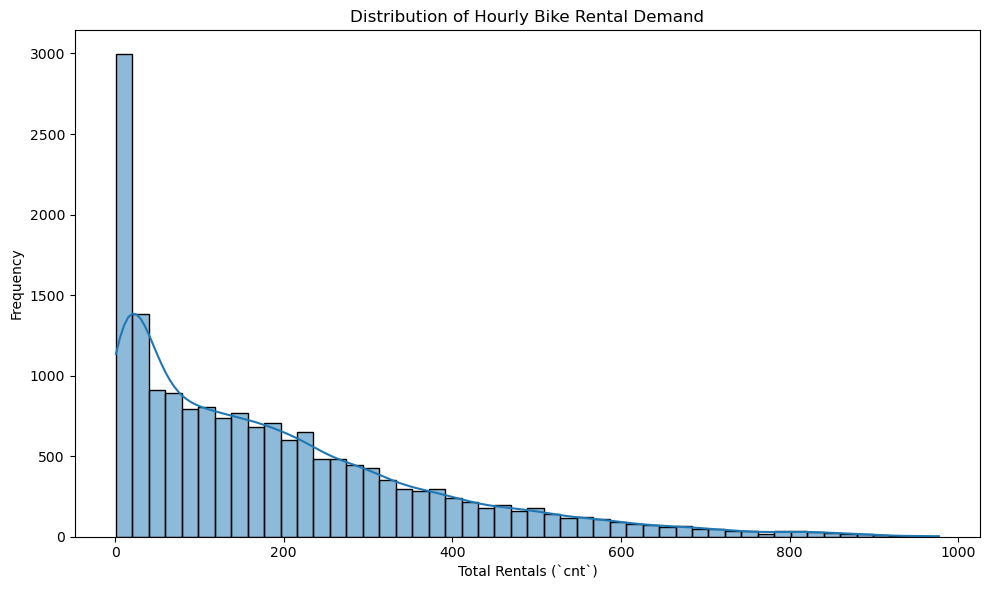

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="cnt",
    bins=50,
    kde=True
)

plt.title("Distribution of Hourly Bike Rental Demand")
plt.xlabel("Total Rentals (`cnt`)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

## 2. Demand by Hour

Hourly demand is one of the most important temporal patterns in a bike-sharing system.

We compare the average number of rentals across the 24 hours of the day.

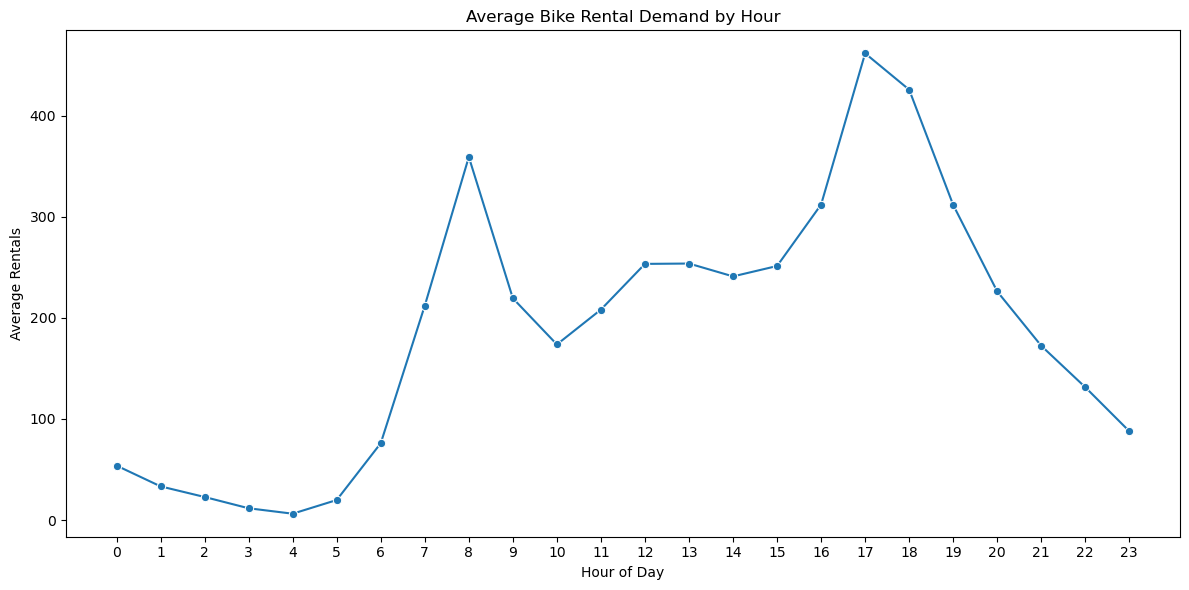

In [18]:
hourly_demand = (
    df.groupby("hr")["cnt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_demand,
    x="hr",
    y="cnt",
    marker="o"
)

plt.title("Average Bike Rental Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.xticks(range(24))
plt.tight_layout()

plt.show()

## 3. Demand by Weekday

We examine whether average hourly demand differs across days of the week.

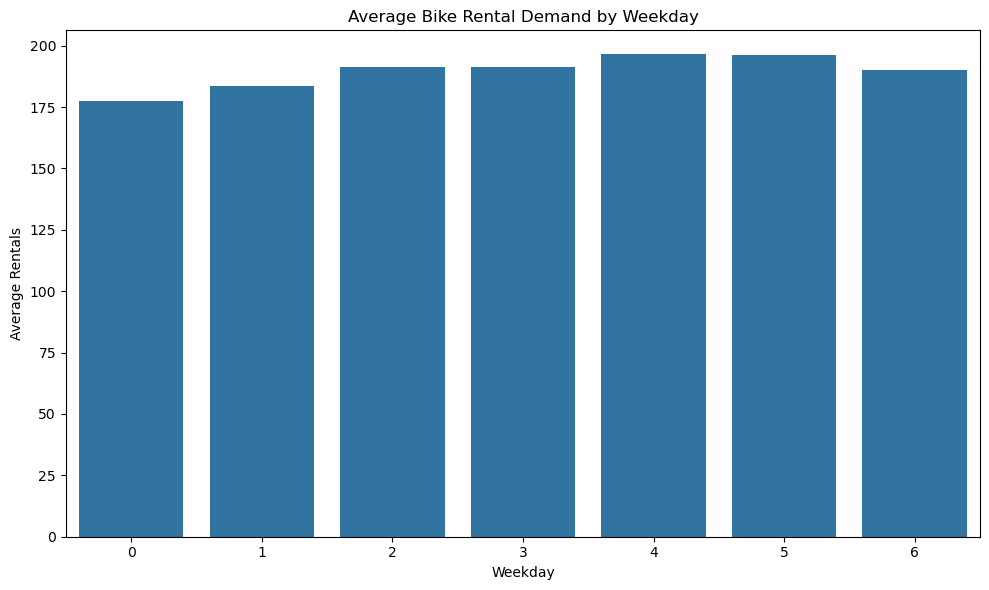

In [19]:
weekday_demand = (
    df.groupby("weekday")["cnt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekday_demand,
    x="weekday",
    y="cnt"
)

plt.title("Average Bike Rental Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Rentals")

plt.tight_layout()
plt.show()

## 4. Demand by Month

We examine how bike rental demand changes throughout the year.

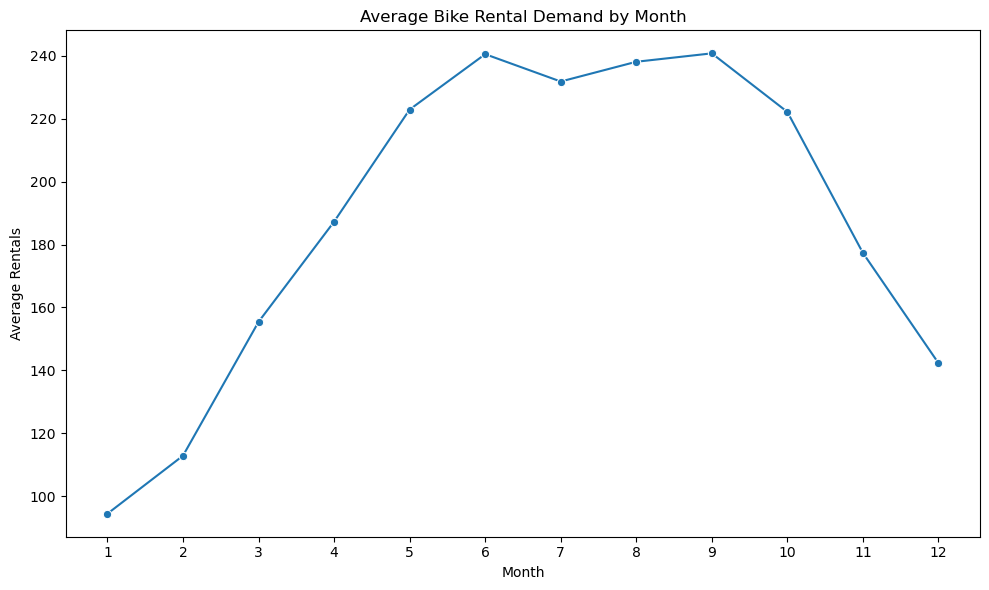

In [20]:
monthly_demand = (
    df.groupby("mnth")["cnt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_demand,
    x="mnth",
    y="cnt",
    marker="o"
)

plt.title("Average Bike Rental Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 5. Demand by Year

The dataset covers two years. We compare average hourly demand between them to identify changes in overall usage.

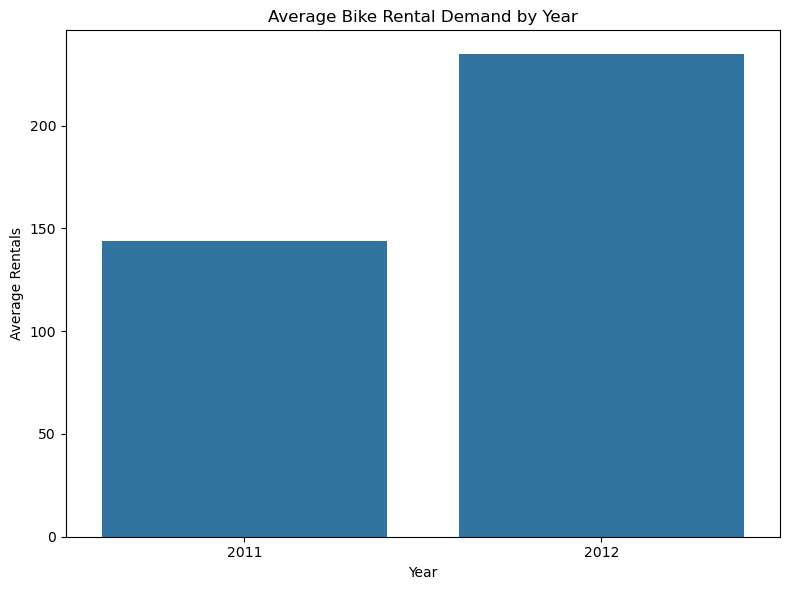

In [21]:
yearly_demand = (
    df.groupby("yr")["cnt"]
    .mean()
    .reset_index()
)

yearly_demand["year"] = yearly_demand["yr"].map({
    0: 2011,
    1: 2012
})

plt.figure(figsize=(8, 6))

sns.barplot(
    data=yearly_demand,
    x="year",
    y="cnt"
)

plt.title("Average Bike Rental Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Rentals")

plt.tight_layout()
plt.show()

## 6. Hourly Demand: Working Days vs. Non-Working Days

Bike-sharing demand may follow different daily patterns depending on whether a day is a working day.

We compare hourly demand across working and non-working days.

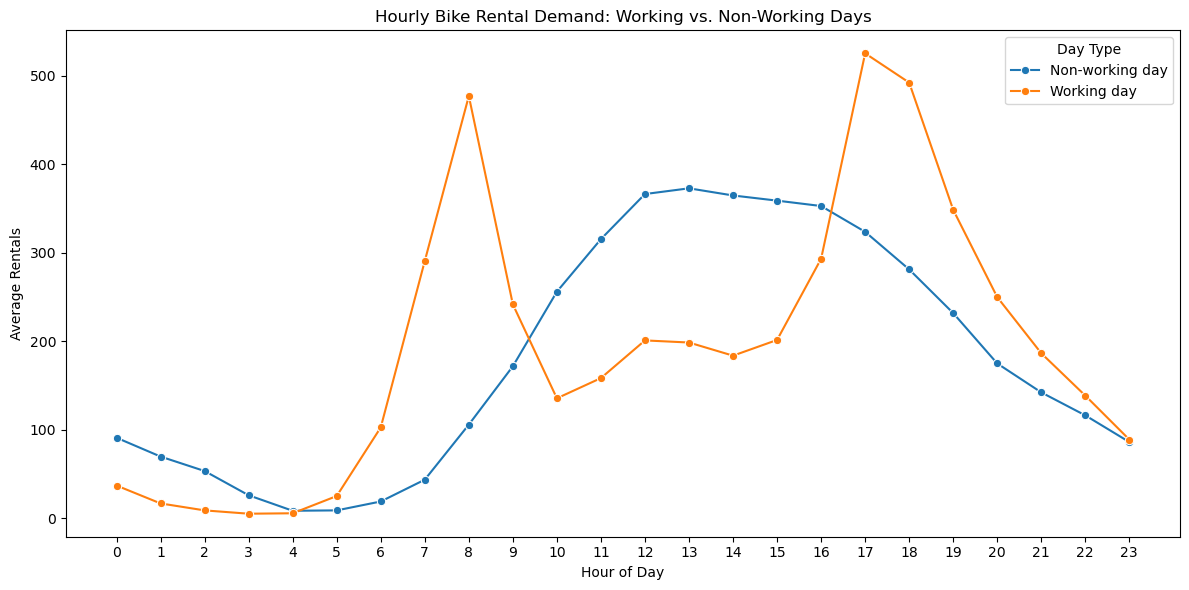

In [22]:
workingday_hourly = (
    df.groupby(["hr", "workingday"])["cnt"]
    .mean()
    .reset_index()
)

workingday_hourly["day_type"] = workingday_hourly["workingday"].map({
    0: "Non-working day",
    1: "Working day"
})

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=workingday_hourly,
    x="hr",
    y="cnt",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Bike Rental Demand: Working vs. Non-Working Days")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.xticks(range(24))
plt.legend(title="Day Type")

plt.tight_layout()
plt.show()

## 7. Demand by Season

We examine differences in average bike rental demand across the four seasons.

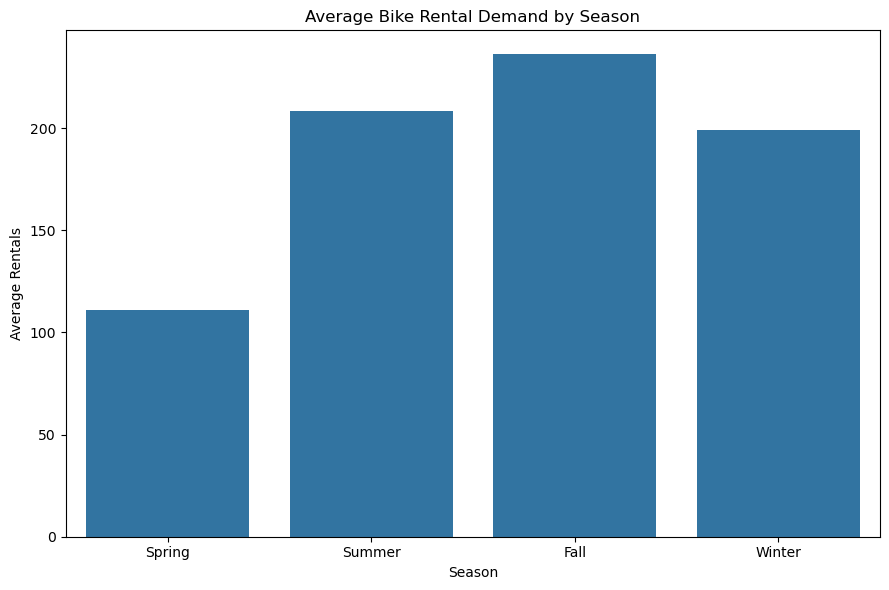

In [23]:
season_demand = (
    df.groupby("season")["cnt"]
    .mean()
    .reset_index()
)

season_demand["season_name"] = season_demand["season"].map({
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
})

plt.figure(figsize=(9, 6))

sns.barplot(
    data=season_demand,
    x="season_name",
    y="cnt"
)

plt.title("Average Bike Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")

plt.tight_layout()
plt.show()

## 8. Demand by Weather Situation

The `weathersit` variable describes the overall weather conditions.

We compare rental demand across the different weather categories.

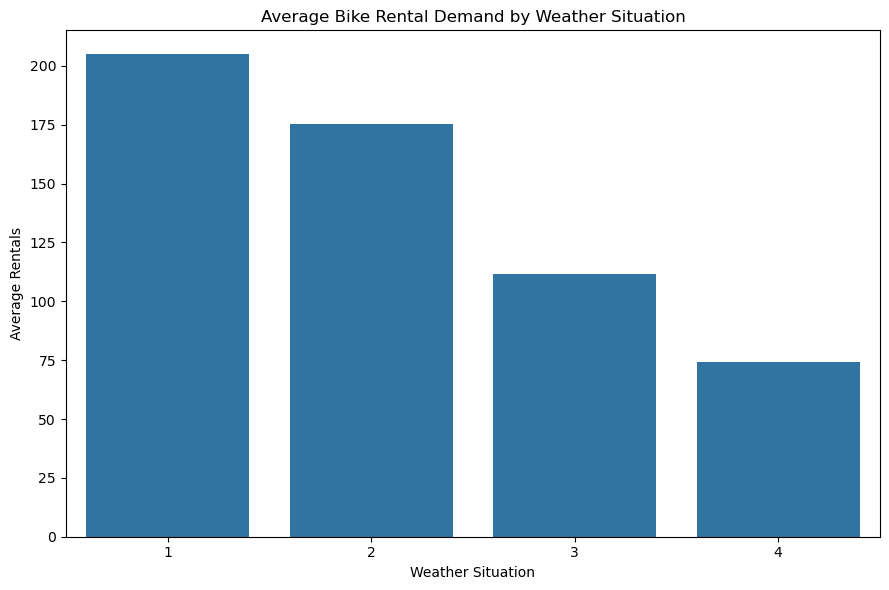

In [24]:
weather_demand = (
    df.groupby("weathersit")["cnt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=weather_demand,
    x="weathersit",
    y="cnt"
)

plt.title("Average Bike Rental Demand by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")

plt.tight_layout()
plt.show()

## 9. Temperature vs. Bike Rental Demand

We investigate the relationship between normalized temperature and total rental demand.

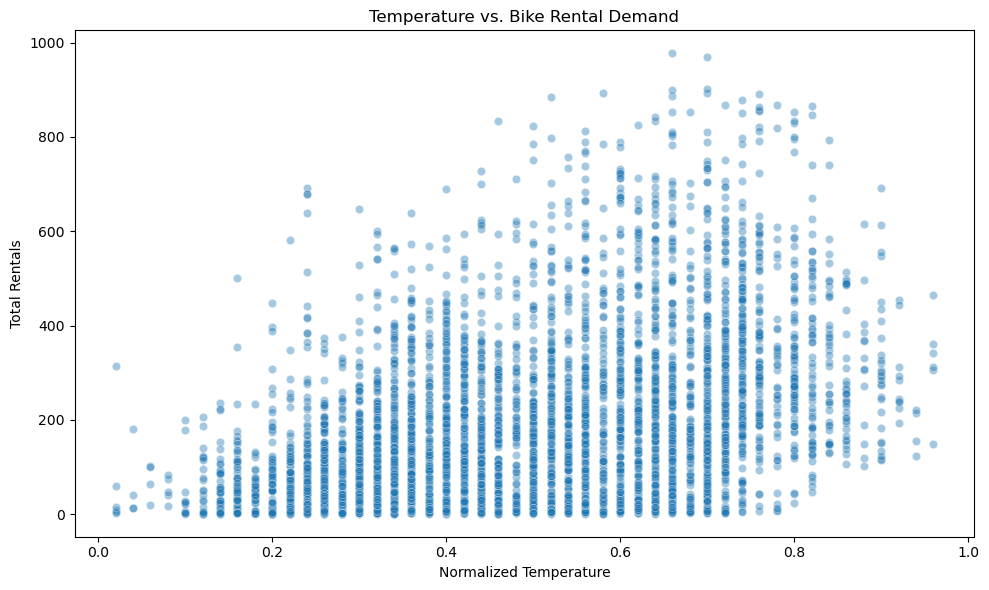

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="temp",
    y="cnt",
    alpha=0.4
)

plt.title("Temperature vs. Bike Rental Demand")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

## 10. Humidity vs. Bike Rental Demand

We examine whether rental demand changes with normalized humidity.

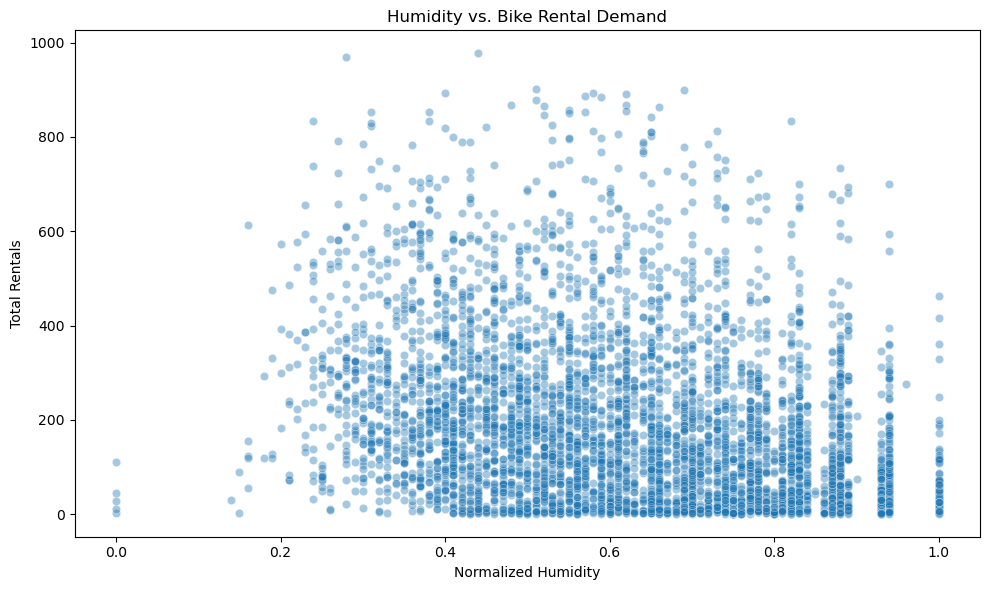

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="hum",
    y="cnt",
    alpha=0.4
)

plt.title("Humidity vs. Bike Rental Demand")
plt.xlabel("Normalized Humidity")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

## 11. Casual vs. Registered Users

The dataset separates rentals into two user groups:

- `casual`: non-registered users
- `registered`: registered users

This analysis is used to understand user behavior.

These variables will **not** be used as predictors of `cnt` because:

`cnt = casual + registered`

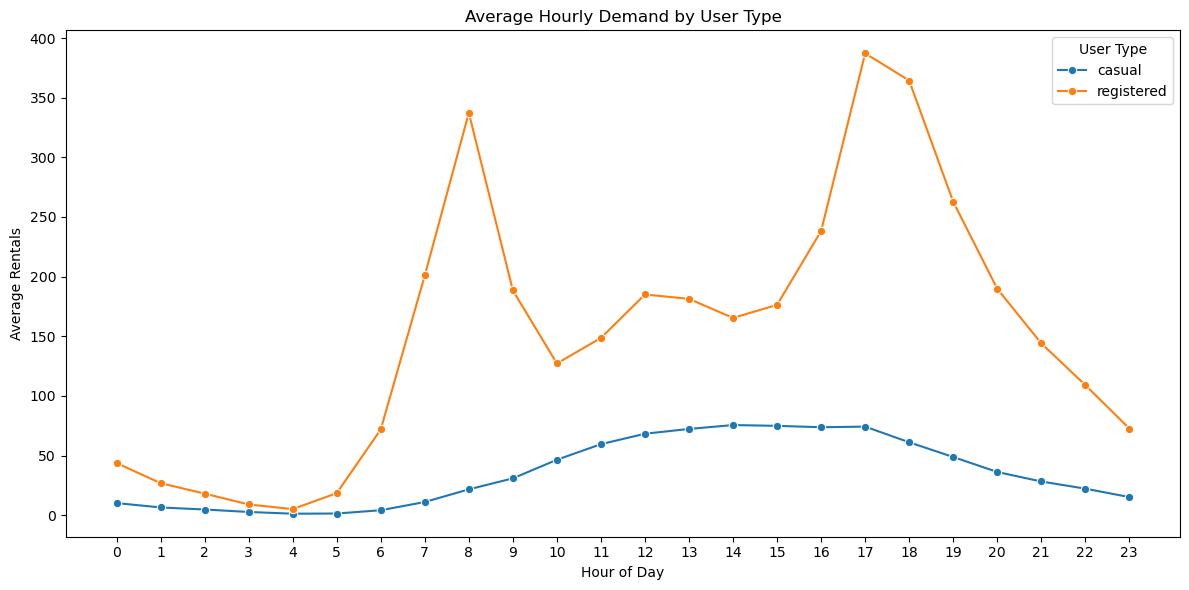

In [27]:
user_hourly = (
    df.groupby("hr")[["casual", "registered"]]
    .mean()
    .reset_index()
)

user_hourly_long = user_hourly.melt(
    id_vars="hr",
    value_vars=["casual", "registered"],
    var_name="user_type",
    value_name="average_rentals"
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=user_hourly_long,
    x="hr",
    y="average_rentals",
    hue="user_type",
    marker="o"
)

plt.title("Average Hourly Demand by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.xticks(range(24))
plt.legend(title="User Type")

plt.tight_layout()
plt.show()

## 12. Correlation Analysis

We examine linear correlations between numerical variables.

Correlation does not imply causation, so the results are interpreted as associations rather than causal effects.

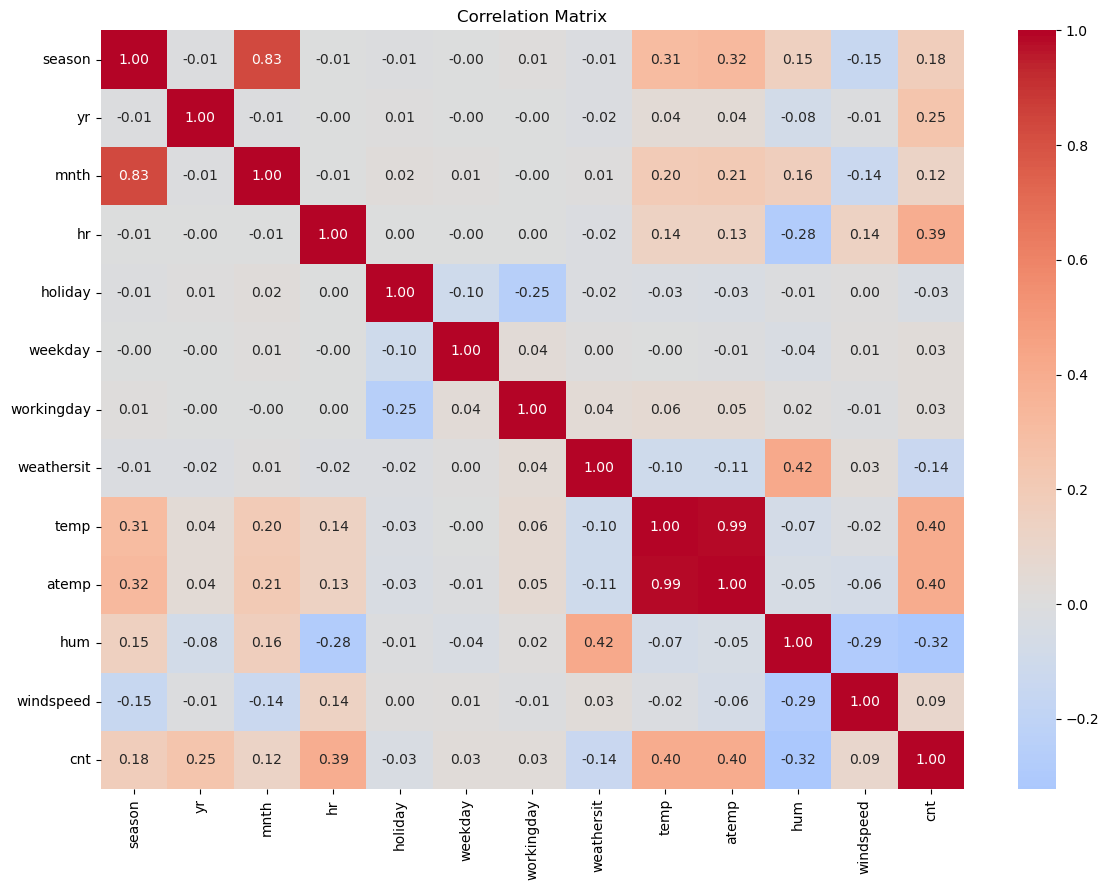

In [28]:
correlation_columns = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

## 13. Summary of Major Demand Patterns

We calculate a few summary statistics that will help us compare the strongest observed differences in demand.

In [29]:
summary_tables = {
    "By Hour": df.groupby("hr")["cnt"].mean(),
    "By Month": df.groupby("mnth")["cnt"].mean(),
    "By Season": df.groupby("season")["cnt"].mean(),
    "By Weather": df.groupby("weathersit")["cnt"].mean(),
    "By Working Day": df.groupby("workingday")["cnt"].mean()
}

for name, table in summary_tables.items():
    print(f"\n{name}")
    print(table.round(2))


By Hour
hr
0     53.90
1     33.38
2     22.87
3     11.73
4      6.35
5     19.89
6     76.04
7    212.06
8    359.01
9    219.31
10   173.67
11   208.14
12   253.32
13   253.66
14   240.95
15   251.23
16   311.98
17   461.45
18   425.51
19   311.52
20   226.03
21   172.31
22   131.34
23    87.83
Name: cnt, dtype: float64

By Month
mnth
1     94.42
2    112.87
3    155.41
4    187.26
5    222.91
6    240.52
7    231.82
8    238.10
9    240.77
10   222.16
11   177.34
12   142.30
Name: cnt, dtype: float64

By Season
season
1   111.11
2   208.34
3   236.02
4   198.87
Name: cnt, dtype: float64

By Weather
weathersit
1   204.87
2   175.17
3   111.58
4    74.33
Name: cnt, dtype: float64

By Working Day
workingday
0   181.41
1   193.21
Name: cnt, dtype: float64


## 14. EDA Conclusions

The exploratory analysis examined bike-sharing demand across:

- Hours of the day
- Weekdays
- Months
- Years
- Working and non-working days
- Seasons
- Weather conditions
- Temperature
- Humidity
- User type

The plots reveal temporal, seasonal, and weather-related patterns in hourly demand.

These observations provide the motivation for feature engineering and predictive modeling.

Importantly, exploratory relationships should not be interpreted as causal effects. The predictive modeling stage will evaluate whether these variables provide useful information for predicting hourly rental demand.

## Export Selected Figures

The following figures are exported for the final project report and GitHub repository.

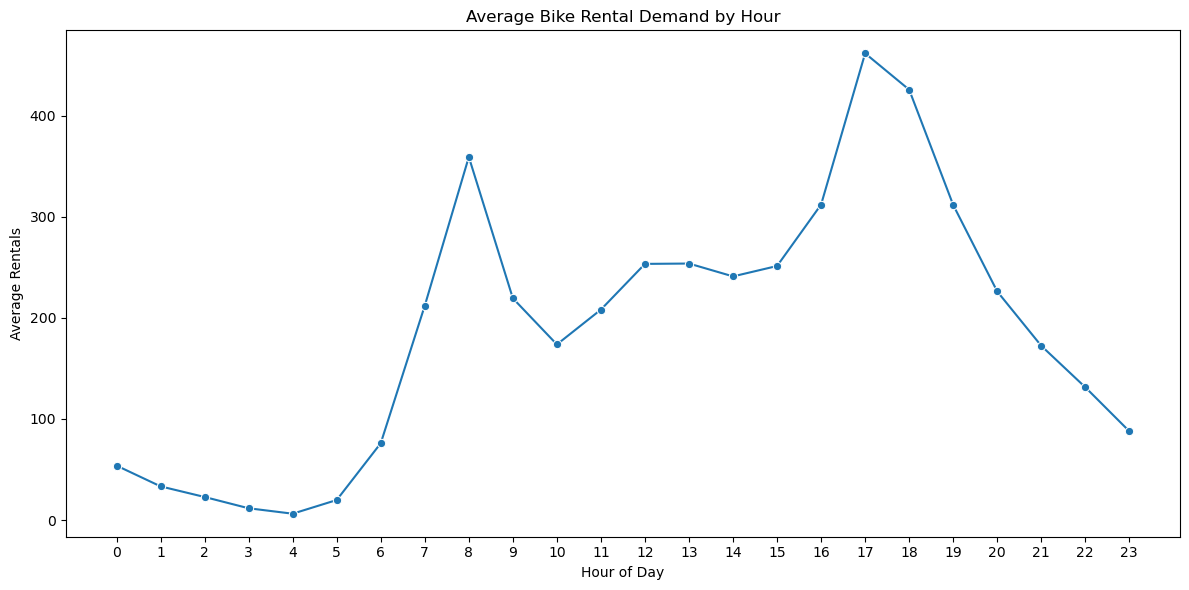

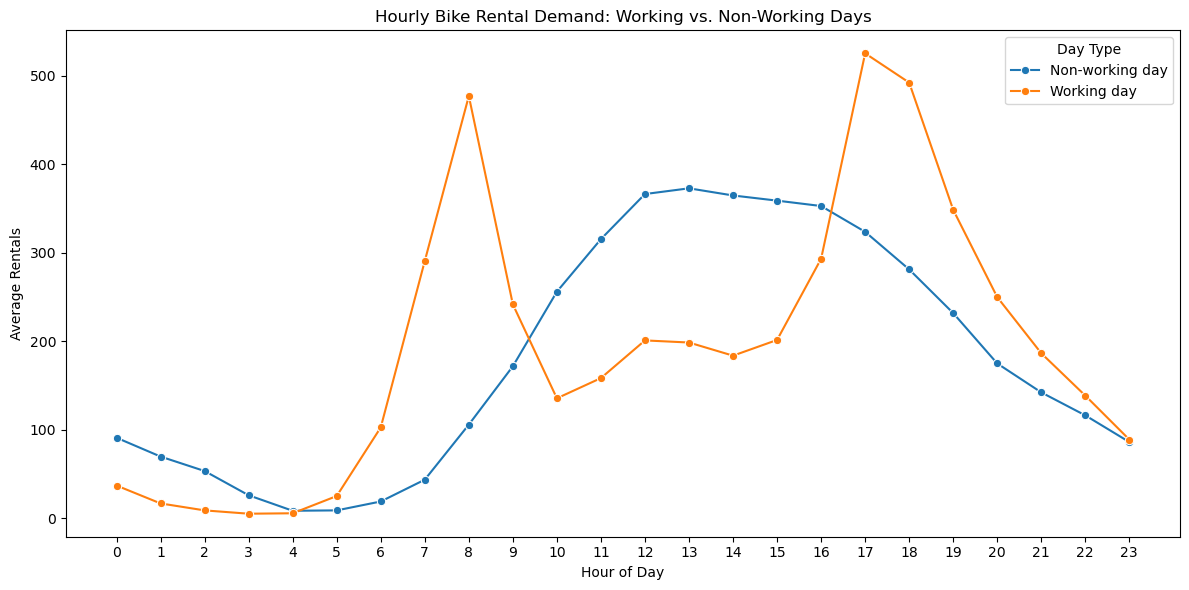

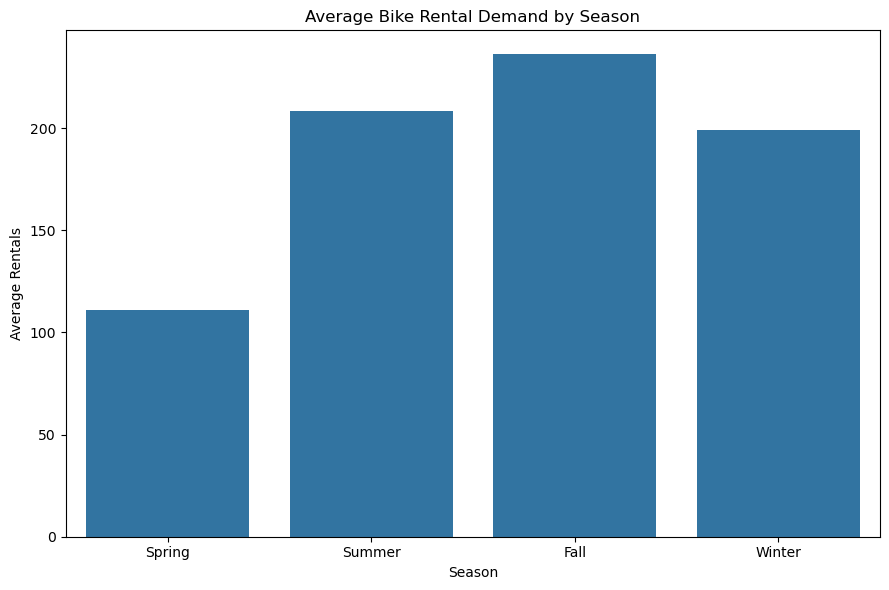

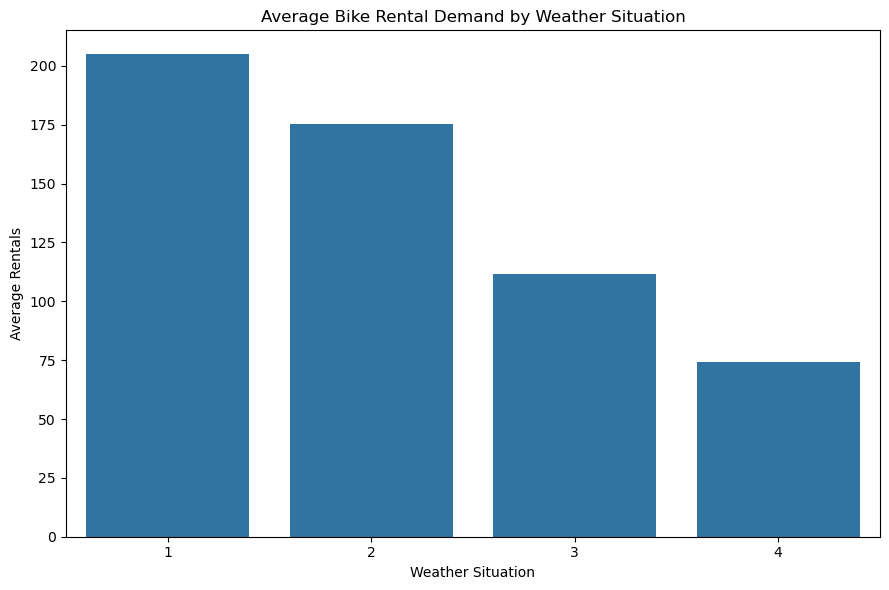

In [30]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.visualization import (
    plot_hourly_demand,
    plot_workingday_hourly_demand,
    plot_seasonal_demand,
    plot_weather_demand,
)


plot_hourly_demand(
    df,
    save_path="../reports/figures/hourly_demand.png",
)

plot_workingday_hourly_demand(
    df,
    save_path="../reports/figures/workingday_hourly_demand.png",
)

plot_seasonal_demand(
    df,
    save_path="../reports/figures/seasonal_demand.png",
)

plot_weather_demand(
    df,
    save_path="../reports/figures/weather_demand.png",
)